# Naive Bayes

Imports and helpers

In [1]:
import scipy.sparse as sp
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.naive_bayes import MultinomialNB
from scipy.stats import loguniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import joblib
import numpy as np

back to root to call functions from helpers.py file

In [2]:
import os
from pathlib import Path
print(Path.cwd())
os.chdir(Path('..').resolve())
from src.utils.helpers import save
print(Path.cwd())

/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning/notebooks
/mnt/d/career/digilians/sentiment-analysis-of-amazon-reviews-using-machine-learning


## Data Acquisition

load dataset

In [3]:
X_train = sp.load_npz('data/vectorizers/X_train_tfidf.npz')
print(f"X_train shape: {X_train.shape}")
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
print(f"y_train shape: {y_train.shape}")

X_train shape: (79972, 50000)
y_train shape: (79972,)


In [4]:
X_valid = sp.load_npz('data/vectorizers/X_valid_tfidf.npz')
print(f"X_valid shape: {X_valid.shape}")
y_valid = pd.read_csv('data/processed/y_valid.csv').squeeze()
print(f"y_valid shape: {y_valid.shape}")

X_valid shape: (20000, 50000)
y_valid shape: (20000,)


In [5]:
X_test = sp.load_npz('data/vectorizers/X_test_tfidf.npz')
print(f"X_test shape: {X_test.shape}")
y_test = pd.read_csv('data/processed/y_test.csv').squeeze()
print(f"y_test shape: {y_test.shape}")

X_test shape: (20000, 50000)
y_test shape: (20000,)


## Model Training

model setup and random search 

In [6]:
nb_model = MultinomialNB()
nb_params = {'alpha': loguniform(1e-3, 1e1), 
                 'fit_prior': [True, False]}

Initialize RandomizedSearchCV (3-fold cross-validation acts as our validation set)

In [7]:
nb_search = RandomizedSearchCV(nb_model, nb_params, 
                               n_iter=60, cv=5, scoring='accuracy', 
                               random_state=42, n_jobs=-1, verbose=1)

Extract best models

In [8]:
print("\nTraining Naive Bayes...")
start_time = time.time()
nb_search.fit(X_train, y_train)
nb_train_time = time.time() - start_time
print(f"Naive Bayes training completed in {nb_train_time:.2f}s.")
print("Let's choose the best estimator...")
best_nb = nb_search.best_estimator_
print(f"Best Naive Bayes Params: {nb_search.best_params_}")


Training Naive Bayes...
Fitting 5 folds for each of 60 candidates, totalling 300 fits
Naive Bayes training completed in 20.46s.
Let's choose the best estimator...
Best Naive Bayes Params: {'alpha': np.float64(1.2604664585649468), 'fit_prior': False}


## Model Evaluation

Predict on the X_valid 

In [9]:
y_valid_pred = best_nb.predict(X_valid)
print(f"Validation Accuracy: {accuracy_score(y_valid, y_valid_pred):.4f}")

Validation Accuracy: 0.8600


Classification Report

In [10]:
print("Classification Report:")
print(classification_report(y_valid, y_valid_pred, target_names=['Negative', 'Positive']))
print(f"Training Time: {nb_train_time:.4f} seconds")

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.87      0.86     10003
    Positive       0.86      0.85      0.86      9997

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000

Training Time: 20.4638 seconds


confusion matrices

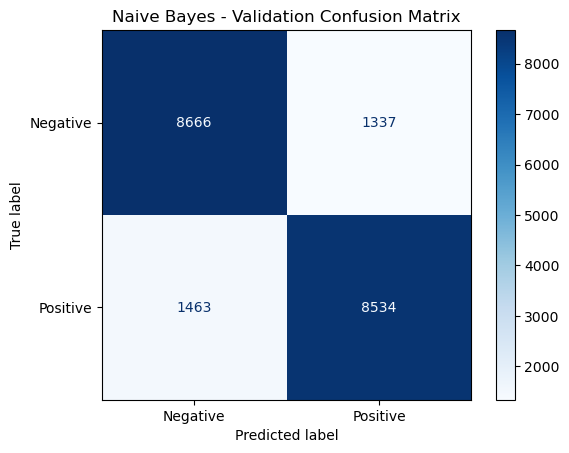

Confusion Matrix:
[[8666 1337]
 [1463 8534]]

True Negatives: 8666
False Positives: 1337
False Negatives: 1463
True Positives: 8534


In [11]:
cm_valid = confusion_matrix(y_valid, y_valid_pred)
ConfusionMatrixDisplay(cm_valid, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Naive Bayes - Validation Confusion Matrix')
plt.savefig('data/predictions/naive_bayes_validation_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm_valid}")
print(f"\nTrue Negatives: {cm_valid[0,0]}")
print(f"False Positives: {cm_valid[0,1]}")
print(f"False Negatives: {cm_valid[1,0]}")
print(f"True Positives: {cm_valid[1,1]}")

based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on tr

## Model Testing

Predict on the X_test 

In [12]:
y_test_pred = best_nb.predict(X_test)
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred):.4f}")

Test Accuracy: 0.8600


Classification Report

In [13]:
print("Classification Report:")
print(classification_report(y_test, y_test_pred, target_names=['Negative', 'Positive']))
print(f"Training Time: {nb_train_time:.4f} seconds")

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.86      0.86      9966
    Positive       0.86      0.86      0.86     10034

    accuracy                           0.86     20000
   macro avg       0.86      0.86      0.86     20000
weighted avg       0.86      0.86      0.86     20000

Training Time: 20.4638 seconds


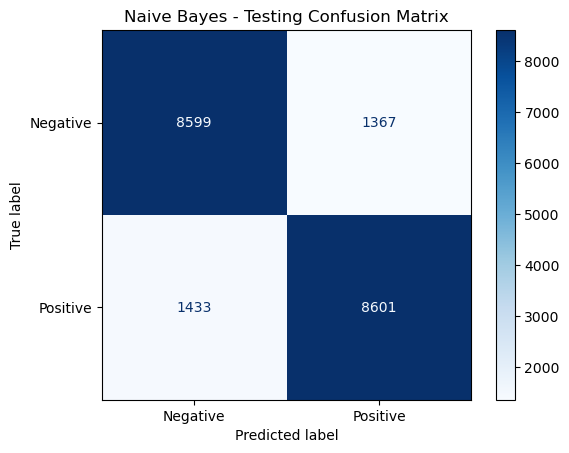

Confusion Matrix:
[[8599 1367]
 [1433 8601]]

True Negatives: 8599
False Positives: 1367
False Negatives: 1433
True Positives: 8601


In [14]:
cm_test = confusion_matrix(y_test, y_test_pred)
ConfusionMatrixDisplay(cm_test, display_labels=['Negative', 'Positive']).plot(cmap='Blues')
plt.title('Naive Bayes - Testing Confusion Matrix')
plt.savefig('data/predictions/naive_bayes_testing_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"Confusion Matrix:\n{cm_test}")
print(f"\nTrue Negatives: {cm_test[0,0]}")
print(f"False Positives: {cm_test[0,1]}")
print(f"False Negatives: {cm_test[1,0]}")
print(f"True Positives: {cm_test[1,1]}")

based on classification report we have `zero data leakage`, and absolutely `zero overfitting` on testing dataset

## visualizations (validation and testing Confusion Matrix)

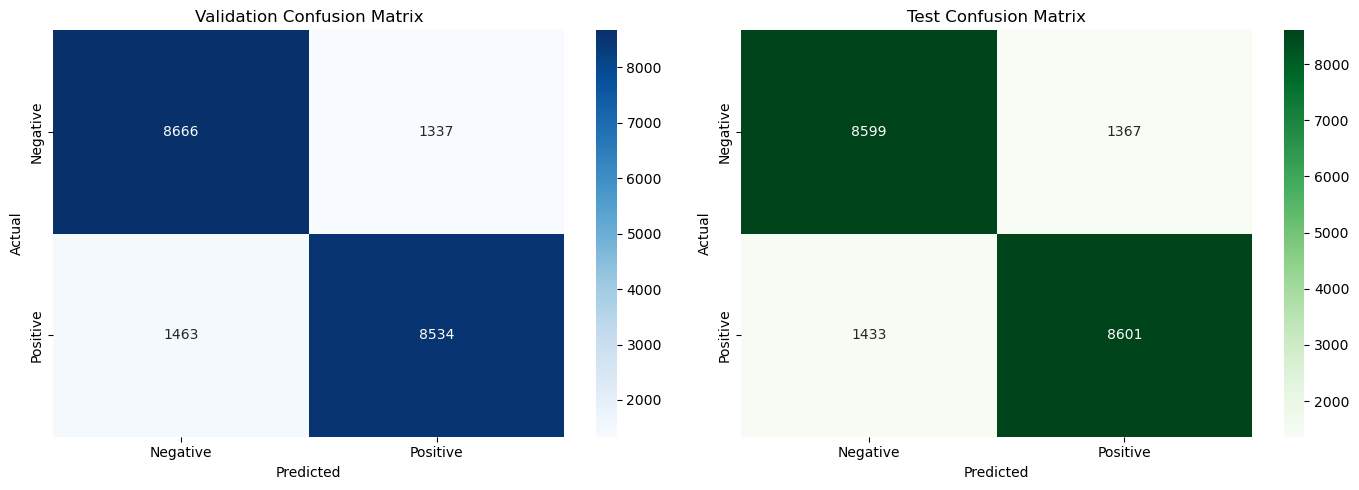

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = best_nb.classes_
ticklabels = ['Negative', 'Positive']

sns.heatmap(confusion_matrix(y_valid, y_valid_pred, labels=classes), 
            annot=True, fmt='d', cmap='Blues', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[0])
axes[0].set_title('Validation Confusion Matrix')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

sns.heatmap(confusion_matrix(y_test, y_test_pred, labels=classes), 
            annot=True, fmt='d', cmap='Greens', xticklabels=ticklabels, yticklabels=ticklabels, ax=axes[1])
axes[1].set_title('Test Confusion Matrix')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')
plt.tight_layout()
plt.savefig('data/predictions/naive_bayes_valid_test_confusion_matrices.png', dpi=300, bbox_inches='tight')
plt.show()

## Feature Inspection

In [ ]:
vec_path = Path('data/vectorizers/tfidf_vectorizer.joblib')

vectorizer_obj = globals().get('vectorizer', None)
if vectorizer_obj is None and vec_path.exists():
    try:
        vectorizer_obj = joblib.load(vec_path)
    except Exception:
        vectorizer_obj = None

if hasattr(best_nb, 'feature_log_prob_') and vectorizer_obj is not None:
    feature_names = (vectorizer_obj.get_feature_names_out()
                     if hasattr(vectorizer_obj, 'get_feature_names_out')
                     else vectorizer_obj.get_feature_names())

    classes = best_nb.classes_
    # determine positive/negative class indices (assumes labels 1 and 2 as in this notebook)
    if 2 in classes and 1 in classes:
        pos_idx = int(np.where(classes == 2)[0][0])
        neg_idx = int(np.where(classes == 1)[0][0])
    else:
        pos_idx, neg_idx = 1, 0  # fallback

    diff = best_nb.feature_log_prob_[pos_idx] - best_nb.feature_log_prob_[neg_idx]
    top_pos_idx = diff.argsort()[::-1][:20]
    top_neg_idx = diff.argsort()[:20]

    print('Top features indicating Positive sentiment:')
    for i in top_pos_idx:
        print(f"{feature_names[i]:<20} {diff[i]:.4f}")

    print('\nTop features indicating Negative sentiment:')
    for i in top_neg_idx:
        print(f"{feature_names[i]:<20} {diff[i]:.4f}")
else:
    print('Vectorizer not found or model lacks feature_log_prob_. Save vectorizer to data/vectorizers/tfidf_vectorizer.joblib to enable feature inspection.')


Top features indicating Positive sentiment:
book            -5.5286
great           -5.8253
not             -5.8276
but             -5.9748
one             -6.0565
very            -6.1054
good            -6.1312
love            -6.1968
like            -6.2554
read            -6.3198
movie           -6.3876
well            -6.4115
time            -6.4214
cd              -6.5023
would           -6.5047

Top features indicating Negative sentiment:
not             -5.1702
book            -5.6727
but             -5.7870
would           -6.0625
one             -6.0780
like            -6.2675
very            -6.3313
no              -6.3338
movie           -6.3513
time            -6.3924
get             -6.4093
product         -6.4756
good            -6.5207
even            -6.5825
money           -6.6159


## Saving the Model

In [18]:
save(model_base='data/models', model=best_nb, model_name='06_naive_bayes_classifier.joblib')

Saved model 06_naive_bayes_classifier.joblib to data/models/06_naive_bayes_classifier.joblib


{'model': PosixPath('data/models/06_naive_bayes_classifier.joblib')}

## Summary